# 🧪 PINN AGNR — Test & Validation Notebook

Comprehensive evaluation suite for the **Physics-Informed Neural Network (PINN)** 
that predicts impurity concentration in *7-AGNR* devices from normalised transmission spectra.

## What this notebook does

| Section | Description |
|---|---|
| **Setup** | Imports, paths, device selection |
| **Data** | Pristine spectrum, manifest, dataset construction |
| **Model** | Load `ImprovedConductanceCNN` checkpoint |
| **Physics module** | Build `DifferentiableMisfit` from file-averaged spectra |
| **Validation** | Evaluate on held-out validation split |
| **Visualisations** | Scatter, box-plot, heatmap, residuals, CDF, MAPE |
| **Report** | Full quantitative summary with R², Pearson/Spearman, % within thresholds |
| **Test (opt.)** | On-the-fly generation of unseen configs for true test-set evaluation |


## 1 — Setup & Imports

In [1]:
import os, sys, copy
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset

# ── Import PINN module ──
from pinn_agnr import (
    ImprovedConductanceCNN,
    DifferentiableMisfit,
    NormalizedTransmissionsDataset,
    NormalizedTestDataset,
    build_misfit_module,
    test_pinn,
)

# ── Plotting style ──
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
})
sns.set_palette("muted")

print("✓ All imports successful")

✓ All imports successful


## 2 — Paths & Configuration

In [2]:
# ── Paths (edit if necessary) ──
PROJECT_ROOT = Path(os.getcwd()).parents[1]
DATA_DIR     = PROJECT_ROOT / "data" / "raw" / "transmission_results"
MANIFEST_PATH = Path(os.getcwd()) / "manifest_agnr.csv"
LEADS_PATH   = PROJECT_ROOT / "leads" / "agnr_7.npy"
PRISTINE_PATH = DATA_DIR / "pristine.npy"

# ── Hyper-parameters (must match training) ──
SPECTRUM_LENGTH = 200
CONC_RANGE      = np.arange(1, 50, 2)  # 25 concentrations: 1,3,5,…,49
MISFIT_WEIGHT   = 0.1
BATCH_SIZE      = 64
VAL_SPLIT       = 0.2

# ── Checkpoint path (set to your saved .pt file) ──
CHECKPOINT_PATH = None  # e.g. "pinn_agnr_best.pt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Data dir exists: {DATA_DIR.exists()}")
print(f"Manifest exists: {MANIFEST_PATH.exists()}")
print(f"Pristine exists: {PRISTINE_PATH.exists()}")

Device: cpu
Data dir exists: True
Manifest exists: True
Pristine exists: True


## 3 — Load Pristine Spectrum

Pristine spectrum shape: (300,)


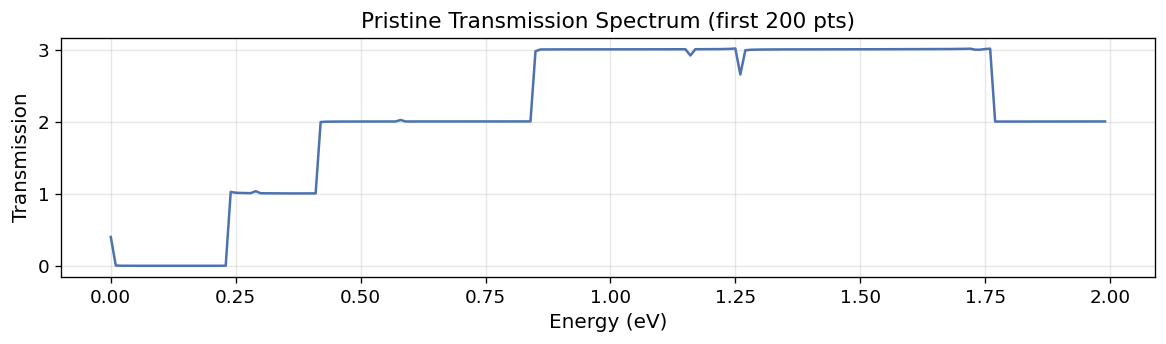

In [3]:
pristine = np.load(str(PRISTINE_PATH))
print(f"Pristine spectrum shape: {pristine.shape}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(0, 3, 0.01)[:SPECTRUM_LENGTH], pristine[:SPECTRUM_LENGTH],
        color="#4C72B0", lw=1.5)
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Transmission")
ax.set_title("Pristine Transmission Spectrum (first 200 pts)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4 — Build Dataset & Train/Val Split

In [4]:
dataset = NormalizedTransmissionsDataset(
    manifest_file=str(MANIFEST_PATH),
    root_dir=str(DATA_DIR),
    pristine=pristine,
    spectrum_length=SPECTRUM_LENGTH,
)
print(f"Full dataset size: {len(dataset)}")

# Reproducible split
n_val   = int(len(dataset) * VAL_SPLIT)
n_train = len(dataset) - n_val
generator = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {n_train}  |  Val: {n_val}")

Full dataset size: 250000
Train: 200000  |  Val: 50000


## 5 — Build DifferentiableMisfit Module

We reconstruct the physics regularizer from the raw `.npy` data files by averaging 
over 100 configurations per concentration.

In [5]:
def _build_misfit_from_files():
    ref_list = []
    for con in CONC_RANGE:
        acc = []
        sample_configs = 100
        for cfg in range(sample_configs):
            fpath = DATA_DIR / f"7_agnr_conc{int(con)}_cfg{cfg}.npy"
            if fpath.exists():
                spec = np.load(str(fpath)).astype(np.float32)[:SPECTRUM_LENGTH]
                spec = np.clip(spec, 0, pristine[:SPECTRUM_LENGTH])
                acc.append(spec)
        if len(acc) == 0:
            raise FileNotFoundError(f"No data for concentration {con}")
        avg_spec = np.mean(acc, axis=0)
        ref_normalised = avg_spec / (pristine[:SPECTRUM_LENGTH] + 1e-8)
        ref_list.append(ref_normalised)

    ref_spectra    = torch.tensor(np.array(ref_list), dtype=torch.float32)
    concentrations = torch.tensor(CONC_RANGE, dtype=torch.float32)
    return DifferentiableMisfit(ref_spectra, concentrations).to(DEVICE)

print("Building DifferentiableMisfit module…")
misfit_module = _build_misfit_from_files()
print("✓ Done!")

Building DifferentiableMisfit module…
✓ Done!


## 6 — Load Model

Set `CHECKPOINT_PATH` above to your saved `.pt` checkpoint.  
If unset, a **freshly initialised** (untrained) model is used — predictions will be random.

In [6]:
model = ImprovedConductanceCNN(input_length=SPECTRUM_LENGTH).to(DEVICE)

if CHECKPOINT_PATH is not None and os.path.exists(CHECKPOINT_PATH):
    state = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    if isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    else:
        model.load_state_dict(state)
    print(f"✓ Model loaded from: {CHECKPOINT_PATH}")
else:
    print("⚠ No checkpoint loaded — using freshly initialised model.")

model.eval()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

⚠ No checkpoint loaded — using freshly initialised model.
Model parameters: 27,777


## 7 — Evaluation Helpers

In [7]:
@torch.no_grad()
def evaluate(model, loader, misfit_module=None, misfit_weight=MISFIT_WEIGHT):
    model.eval()
    all_preds, all_labels = [], []
    all_mse, all_misfit, all_total = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        preds = model(xb)
        preds_flat, yb_flat = preds.squeeze(-1), yb.squeeze(-1)
        mse = F.mse_loss(preds_flat, yb_flat, reduction="none")

        if misfit_module is not None:
            mis = misfit_module(xb, preds)
            total = mse.mean() + misfit_weight * mis
            all_misfit.append(mis.item())
        else:
            total = mse.mean()
            all_misfit.append(0.0)

        all_preds.append(preds_flat.cpu())
        all_labels.append(yb_flat.cpu())
        all_mse.append(mse.mean().item())
        all_total.append(total.item())

    return {
        "preds":  torch.cat(all_preds).numpy(),
        "labels": torch.cat(all_labels).numpy(),
        "mse_losses":    all_mse,
        "misfit_losses": all_misfit,
        "total_losses":  all_total,
    }


def build_results_df(results):
    df = pd.DataFrame({
        "true_conc":  results["labels"],
        "pred_conc":  results["preds"],
    })
    df["error"]     = df["pred_conc"] - df["true_conc"]
    df["abs_error"] = df["error"].abs()
    df["pct_error"] = (df["abs_error"] / (df["true_conc"] + 1e-8)) * 100
    return df


def summary_table(df):
    return df.groupby("true_conc").agg(
        n_samples    = ("abs_error", "count"),
        pred_mean    = ("pred_conc", "mean"),
        pred_std     = ("pred_conc", "std"),
        mae          = ("abs_error", "mean"),
        rmse         = ("abs_error", lambda x: np.sqrt((x**2).mean())),
        max_error    = ("abs_error", "max"),
        median_error = ("abs_error", "median"),
        mape         = ("pct_error", "mean"),
    ).round(3)

print("✓ Evaluation helpers defined")

✓ Evaluation helpers defined


## 8 — Run Validation Evaluation

In [8]:
print("Evaluating on VALIDATION set…")
val_results = evaluate(model, val_loader, misfit_module)
val_df      = build_results_df(val_results)
val_summary = summary_table(val_df)

print(f"\nOverall Val MSE:   {np.mean(val_results['mse_losses']):.4f}")
print(f"Overall Val MAE:   {val_df['abs_error'].mean():.4f}")
print(f"Overall Val MAPE:  {val_df['pct_error'].mean():.2f}%")
print(f"\nPer-concentration summary:")
val_summary

Evaluating on VALIDATION set…

Overall Val MSE:   833.4418
Overall Val MAE:   25.0577
Overall Val MAPE:  99.84%

Per-concentration summary:


,n_samples,pred_mean,pred_std,mae,rmse,max_error,median_error,mape
true_conc,,,,,,,,
1.0,1985,0.017,0.000,0.983,0.983,0.985000,0.983,98.332001
3.0,1928,0.015,0.001,2.985,2.985,2.987000,2.985,99.487000
5.0,1974,0.015,0.001,4.985,4.985,4.987000,4.985,99.705002
7.0,1932,0.014,0.001,6.986,6.986,6.988000,6.986,99.793999
9.0,1956,0.014,0.001,8.986,8.986,8.988000,8.986,99.842003
11.0,1976,0.014,0.001,10.986,10.986,10.988000,10.986,99.871002
13.0,1986,0.014,0.001,12.986,12.986,12.988000,12.986,99.890999
15.0,2038,0.014,0.001,14.986,14.986,14.988000,14.986,99.905998
17.0,2015,0.014,0.001,16.986,16.986,16.989000,16.986,99.917000


## 9 — Visualisations

### 9a — Predicted vs True Concentration

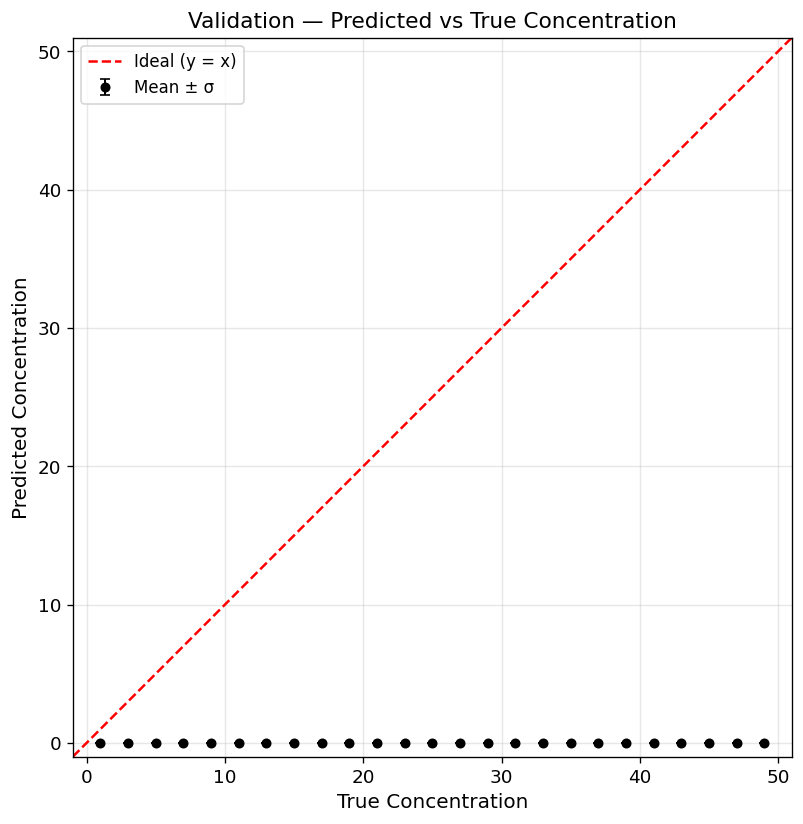

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(val_df["true_conc"], val_df["pred_conc"], alpha=0.15, s=8,
           color="#4C72B0", edgecolors="none", rasterized=True)

lo, hi = CONC_RANGE[0] - 2, CONC_RANGE[-1] + 2
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal (y = x)")

grouped = val_df.groupby("true_conc")["pred_conc"]
means, stds = grouped.mean(), grouped.std()
ax.errorbar(means.index, means.values, yerr=stds.values,
            fmt="ko", ms=5, capsize=3, lw=1.2, label="Mean ± σ")

ax.set_xlabel("True Concentration")
ax.set_ylabel("Predicted Concentration")
ax.set_title("Validation — Predicted vs True Concentration")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9b — Absolute Error by Concentration

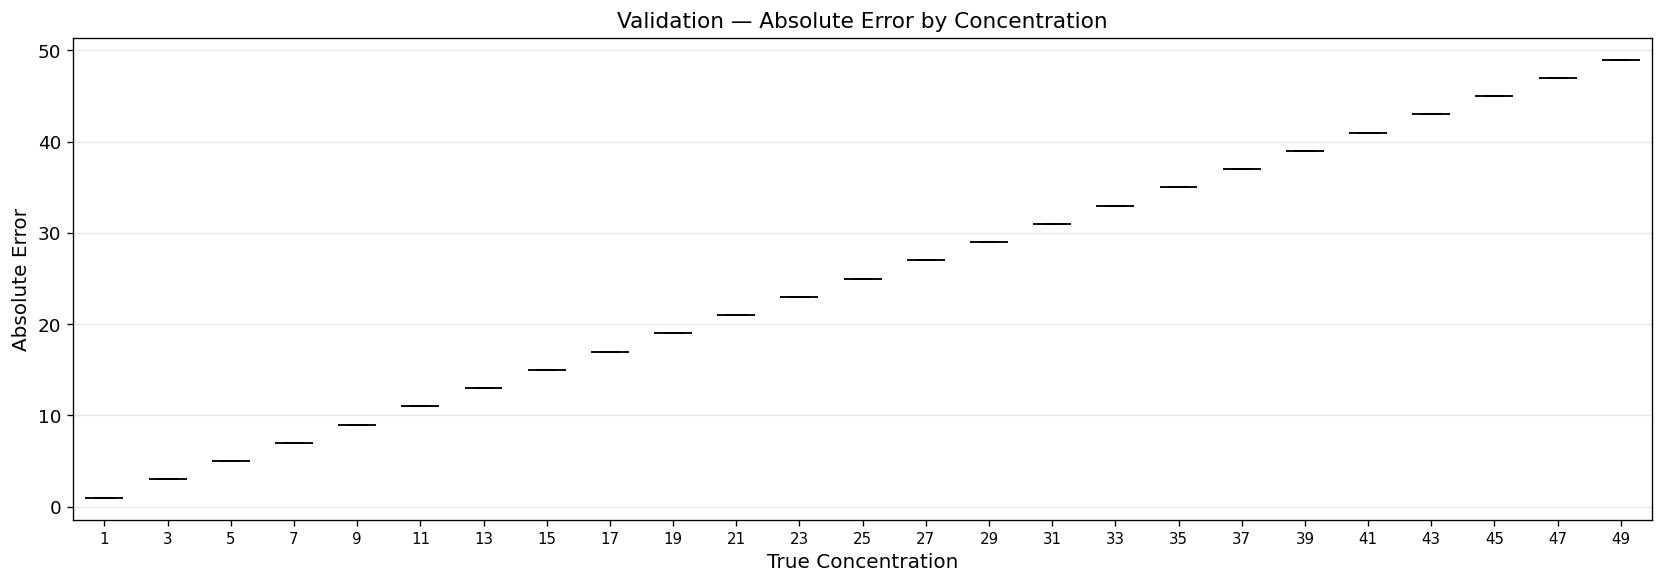

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
concs_sorted = sorted(val_df["true_conc"].unique())
data = [val_df[val_df["true_conc"] == c]["abs_error"].values for c in concs_sorted]

bplot = ax.boxplot(data, positions=range(len(concs_sorted)),
                   widths=0.6, patch_artist=True,
                   showfliers=False, medianprops=dict(color="black"))
for patch in bplot["boxes"]:
    patch.set_facecolor("#7EB1D4"); patch.set_alpha(0.7)

ax.set_xticks(range(len(concs_sorted)))
ax.set_xticklabels([str(int(c)) for c in concs_sorted], fontsize=9)
ax.set_xlabel("True Concentration")
ax.set_ylabel("Absolute Error")
ax.set_title("Validation — Absolute Error by Concentration")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 9c — Prediction Density Heatmap

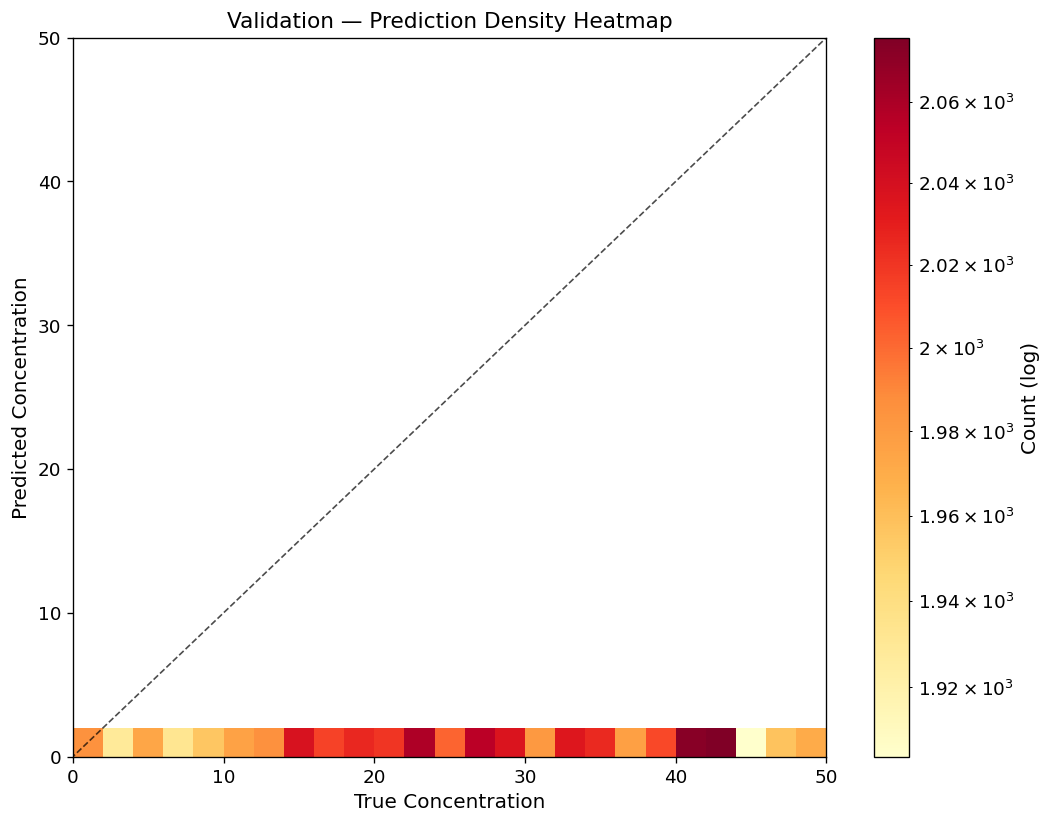

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
bins_x = np.arange(CONC_RANGE[0] - 1, CONC_RANGE[-1] + 3, 2)
bins_y = np.arange(CONC_RANGE[0] - 1, CONC_RANGE[-1] + 3, 2)

h, xedges, yedges, img = ax.hist2d(
    val_df["true_conc"], val_df["pred_conc"],
    bins=[bins_x, bins_y], cmap="YlOrRd", norm=LogNorm())
fig.colorbar(img, ax=ax, label="Count (log)")

lo, hi = CONC_RANGE[0] - 2, CONC_RANGE[-1] + 2
ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.7)
ax.set_xlabel("True Concentration")
ax.set_ylabel("Predicted Concentration")
ax.set_title("Validation — Prediction Density Heatmap")
plt.tight_layout()
plt.show()

### 9d — Residual Distribution & Bias Check

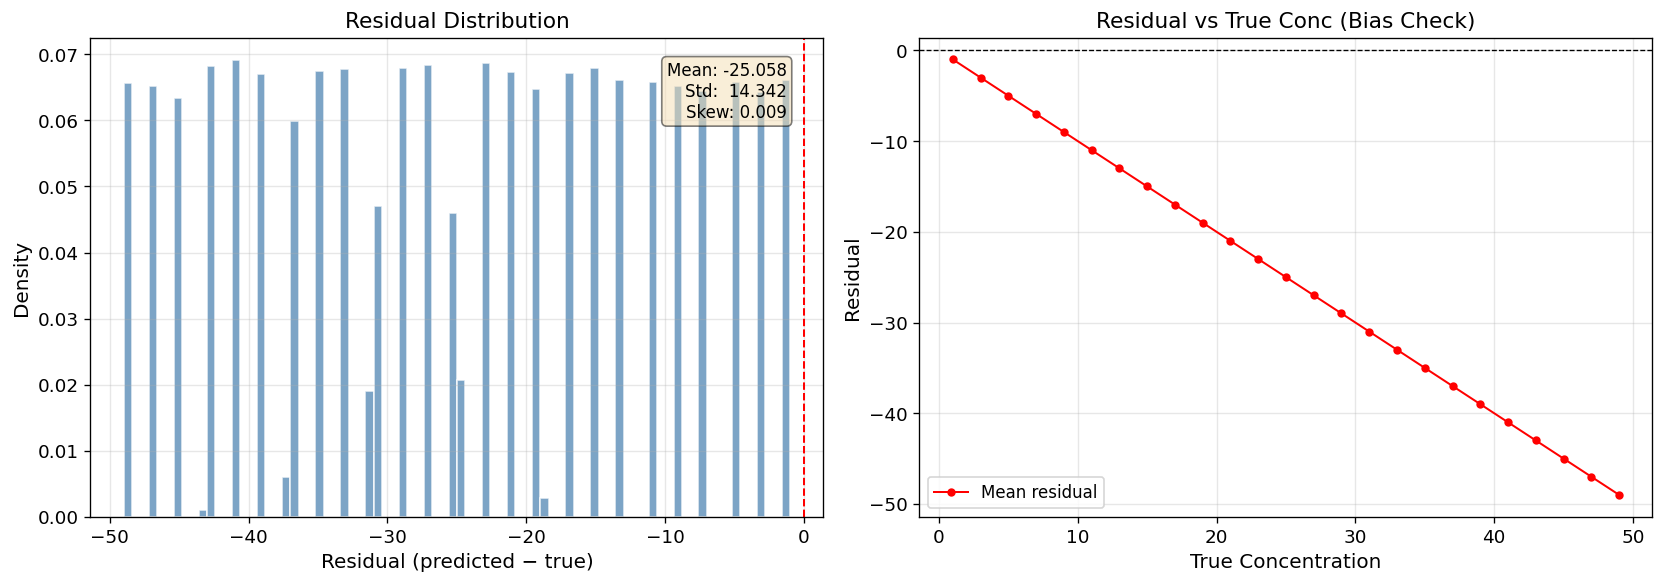

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

residuals = val_df["error"].values
ax1.hist(residuals, bins=80, color="#5B8DB8", edgecolor="white", alpha=0.8, density=True)
ax1.axvline(0, color="red", linestyle="--", lw=1.2)
ax1.set_xlabel("Residual (predicted − true)")
ax1.set_ylabel("Density")
ax1.set_title("Residual Distribution")
ax1.grid(True, alpha=0.3)
stats_text = f"Mean: {residuals.mean():.3f}\nStd:  {residuals.std():.3f}\nSkew: {pd.Series(residuals).skew():.3f}"
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes,
         va="top", ha="right", fontsize=10,
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

ax2.scatter(val_df["true_conc"], val_df["error"], alpha=0.1, s=4,
            color="#4C72B0", edgecolors="none", rasterized=True)
mean_resid = val_df.groupby("true_conc")["error"].mean()
ax2.plot(mean_resid.index, mean_resid.values, "ro-", ms=4, lw=1.2, label="Mean residual")
ax2.axhline(0, color="black", linestyle="--", lw=0.8)
ax2.set_xlabel("True Concentration")
ax2.set_ylabel("Residual")
ax2.set_title("Residual vs True Conc (Bias Check)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9e — MAE & RMSE per Concentration

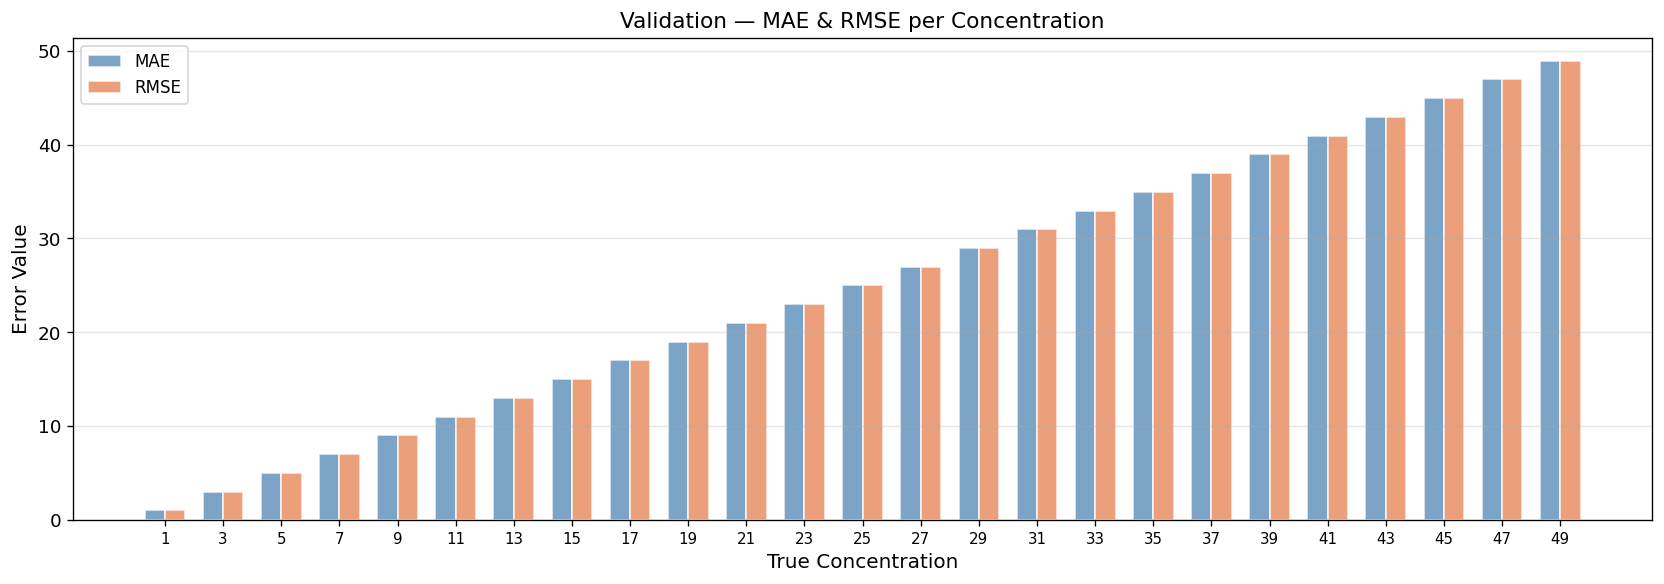

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
concs = val_summary.index.values
x = np.arange(len(concs))
width = 0.35

ax.bar(x - width/2, val_summary["mae"],  width, label="MAE",  color="#5B8DB8", alpha=0.8, edgecolor="white")
ax.bar(x + width/2, val_summary["rmse"], width, label="RMSE", color="#E8875A", alpha=0.8, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([str(int(c)) for c in concs], fontsize=9)
ax.set_xlabel("True Concentration")
ax.set_ylabel("Error Value")
ax.set_title("Validation — MAE & RMSE per Concentration")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 9f — Cumulative Error Distribution

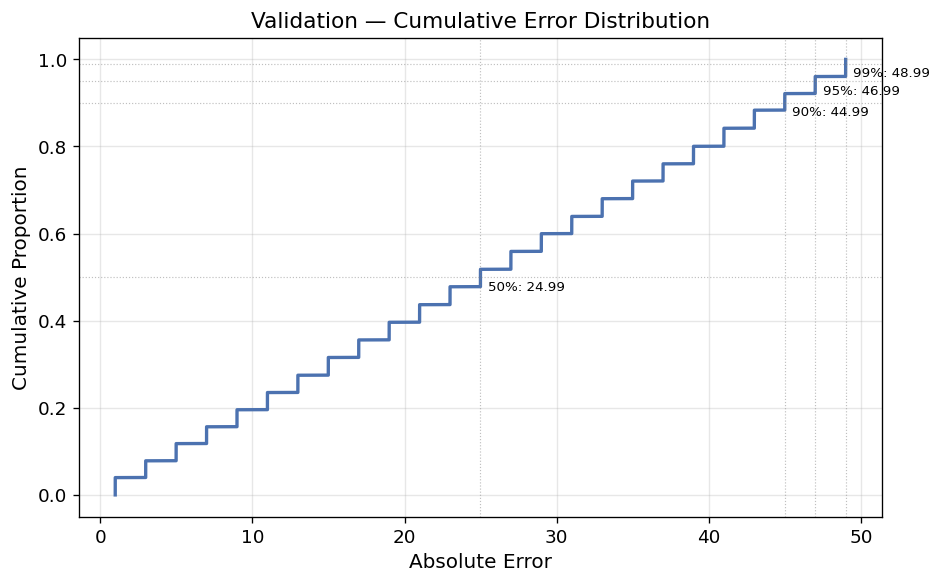

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sorted_errors = np.sort(val_df["abs_error"].values)
cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

ax.plot(sorted_errors, cdf, color="#4C72B0", lw=2)
for pct in [0.5, 0.9, 0.95, 0.99]:
    thr = np.percentile(val_df["abs_error"], pct * 100)
    ax.axhline(pct, color="gray", ls=":", lw=0.7, alpha=0.5)
    ax.axvline(thr, color="gray", ls=":", lw=0.7, alpha=0.5)
    ax.annotate(f"{pct*100:.0f}%: {thr:.2f}", xy=(thr, pct), fontsize=8,
                xytext=(thr + 0.5, pct - 0.03))

ax.set_xlabel("Absolute Error")
ax.set_ylabel("Cumulative Proportion")
ax.set_title("Validation — Cumulative Error Distribution")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9g — MAPE per Concentration

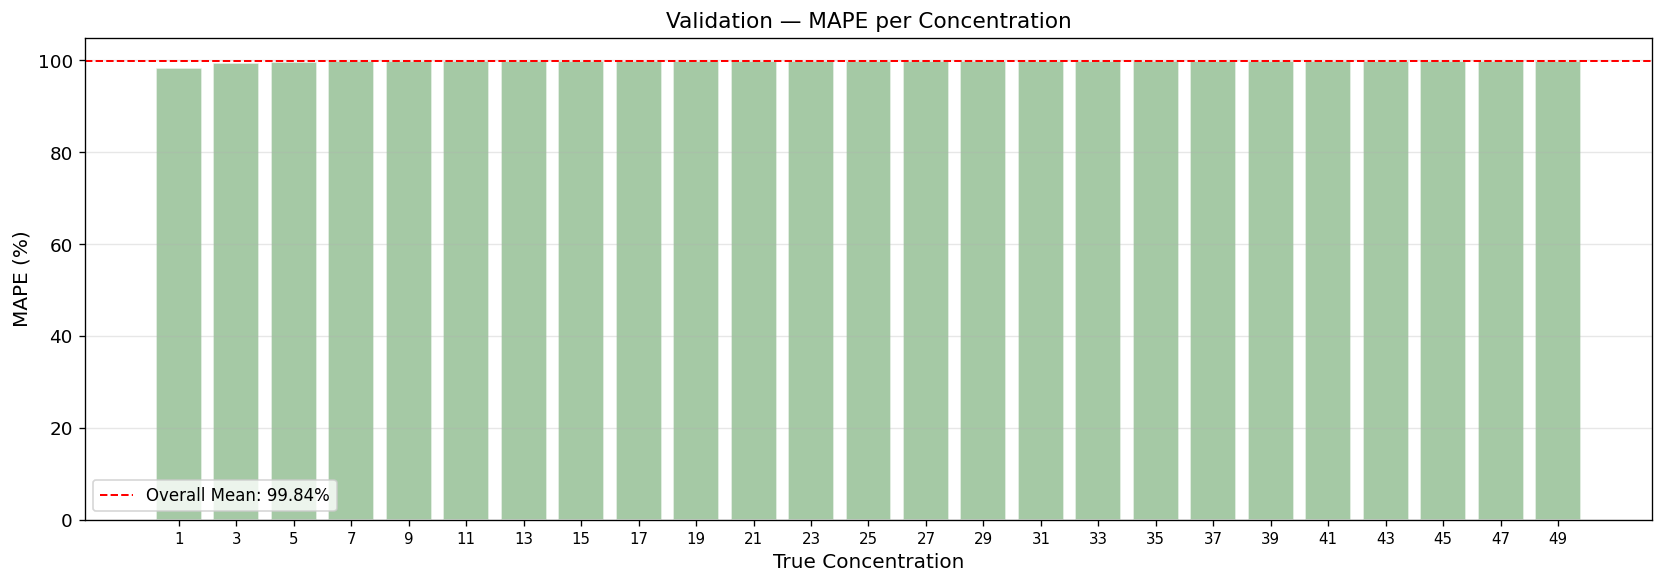

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))
concs = val_summary.index.values
ax.bar(range(len(concs)), val_summary["mape"], color="#8FBC8F", alpha=0.8, edgecolor="white")
ax.axhline(val_summary["mape"].mean(), color="red", linestyle="--", lw=1.2,
           label=f'Overall Mean: {val_summary["mape"].mean():.2f}%')
ax.set_xticks(range(len(concs)))
ax.set_xticklabels([str(int(c)) for c in concs], fontsize=9)
ax.set_xlabel("True Concentration")
ax.set_ylabel("MAPE (%)")
ax.set_title("Validation — MAPE per Concentration")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 10 — Full Quantitative Report

In [16]:
from scipy.stats import pearsonr, spearmanr

print("=" * 70)
print("  PINN AGNR — Validation Report")
print("=" * 70)

print(f"\n  Total samples: {len(val_df)}")
print(f"  Unique concentrations: {val_df['true_conc'].nunique()}")

print(f"\n  ── Global Metrics ──")
print(f"  MAE:           {val_df['abs_error'].mean():.4f}")
print(f"  RMSE:          {np.sqrt((val_df['abs_error']**2).mean()):.4f}")
print(f"  MAPE:          {val_df['pct_error'].mean():.2f}%")
print(f"  Median AE:     {val_df['abs_error'].median():.4f}")
print(f"  Max AE:        {val_df['abs_error'].max():.4f}")
print(f"  Mean Residual: {val_df['error'].mean():.4f} (bias)")
print(f"  Std Residual:  {val_df['error'].std():.4f}")

r, p_r   = pearsonr(val_df["true_conc"], val_df["pred_conc"])
rho, p_rho = spearmanr(val_df["true_conc"], val_df["pred_conc"])
print(f"\n  Pearson  r  = {r:.6f}  (p = {p_r:.2e})")
print(f"  Spearman ρ = {rho:.6f}  (p = {p_rho:.2e})")

ss_res = ((val_df["pred_conc"] - val_df["true_conc"]) ** 2).sum()
ss_tot = ((val_df["true_conc"] - val_df["true_conc"].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f"  R² score   = {r2:.6f}")

print(f"\n  ── % Within Error Threshold ──")
for thresh in [1, 2, 3, 5, 10]:
    pct = (val_df["abs_error"] <= thresh).mean() * 100
    print(f"  Within ±{thresh:>2d}: {pct:6.2f}%")

best_conc  = val_summary["mae"].idxmin()
worst_conc = val_summary["mae"].idxmax()
print(f"\n  Best  conc (lowest MAE):  {int(best_conc)} (MAE={val_summary.loc[best_conc,'mae']:.4f})")
print(f"  Worst conc (highest MAE): {int(worst_conc)} (MAE={val_summary.loc[worst_conc,'mae']:.4f})")
print("=" * 70)

  PINN AGNR — Validation Report

  Total samples: 50000
  Unique concentrations: 25

  ── Global Metrics ──
  MAE:           25.0577
  RMSE:          28.8716
  MAPE:          99.84%
  Median AE:     24.9859
  Max AE:        48.9883
  Mean Residual: -25.0577 (bias)
  Std Residual:  14.3418

  Pearson  r  = -0.269121  (p = 0.00e+00)
  Spearman ρ = -0.195449  (p = 0.00e+00)
  R² score   = -3.052807

  ── % Within Error Threshold ──
  Within ± 1:   3.97%
  Within ± 2:   3.97%
  Within ± 3:   7.83%
  Within ± 5:  11.77%
  Within ±10:  19.55%

  Best  conc (lowest MAE):  1 (MAE=0.9830)
  Worst conc (highest MAE): 49 (MAE=48.9860)


## 11 — (Optional) Evaluate on Held-Out Test Configurations

Uncomment and run the cell below to generate **100 fresh configurations** per concentration 
(configs 10001–10100, never seen during training). This is slow due to on-the-fly quantum 
transport calculations.

In [ ]:
# ── Uncomment the block below to run test evaluation ──

# from ca_agnr import device_transmission
# g_7 = np.load(str(LEADS_PATH))
#
# TEST_CONFIGS = np.arange(10001, 10101, 1)
# TEST_CONCS   = np.arange(1, 50, 2)
#
# print("Generating test data…")
# data_test = {}
# for con in TEST_CONCS:
#     print(f"  Concentration {con}…")
#     data_test[con] = [
#         [device_transmission(w, 0.0001, 1, 0, 7, int(cfg), int(con))
#          for w in np.arange(0, 3, 0.01)]
#         for cfg in TEST_CONFIGS
#     ]
#
# test_ds     = NormalizedTestDataset(data_test, pristine, SPECTRUM_LENGTH)
# test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
#
# print("Evaluating on TEST set…")
# test_results = evaluate(model, test_loader, misfit_module)
# test_df      = build_results_df(test_results)
# test_summary = summary_table(test_df)
# test_summary

## 12 — Save Results

In [ ]:
# Uncomment to save:
# val_df.to_csv("validation_results.csv", index=False)
# val_summary.to_csv("validation_summary.csv")
# print("Saved!")

print("✓ Test & Validation suite completed!")